In [20]:
import pandas as pd
import shap
import os

In [ ]:
os.chdir(r'C:\SML_Projects\SML_gym_fatPercentage_predict_project')

In [22]:
x_train = pd.read_csv('data/engineered/engineered_x_train.csv')
x_test  = pd.read_csv('data/engineered/engineered_x_test.csv')

In [23]:
from joblib import load

pipeline = load('pipeline/full_pipeline.joblib')

preprocess = pipeline.named_steps['prep']
model = pipeline.named_steps['model']

print(type(pipeline.named_steps['prep']))
print(pipeline.named_steps['prep'].__class__.__module__)

X_train_trans = preprocess.transform(x_train)
X_test_trans  = preprocess.transform(x_test)

feature_names = X_train_trans.columns.to_numpy()

<class 'src.train_preprocessing.PreprocessingTrain'>
src.train_preprocessing


# Global SHAP

In [24]:
num_cols = x_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = x_train.select_dtypes(include=["object"]).columns.tolist()

X_train_enc = x_train[num_cols].copy()
X_test_enc  = x_test[num_cols].copy()

In [25]:
explainer = shap.Explainer(
    model.predict,
    X_train_trans
)

In [26]:
shap_values = explainer(X_test_trans[:500])

PermutationExplainer explainer: 196it [02:35,  1.24it/s]                         


C:\Users\User\AppData\Local\Temp\ipykernel_18992\2557961345.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


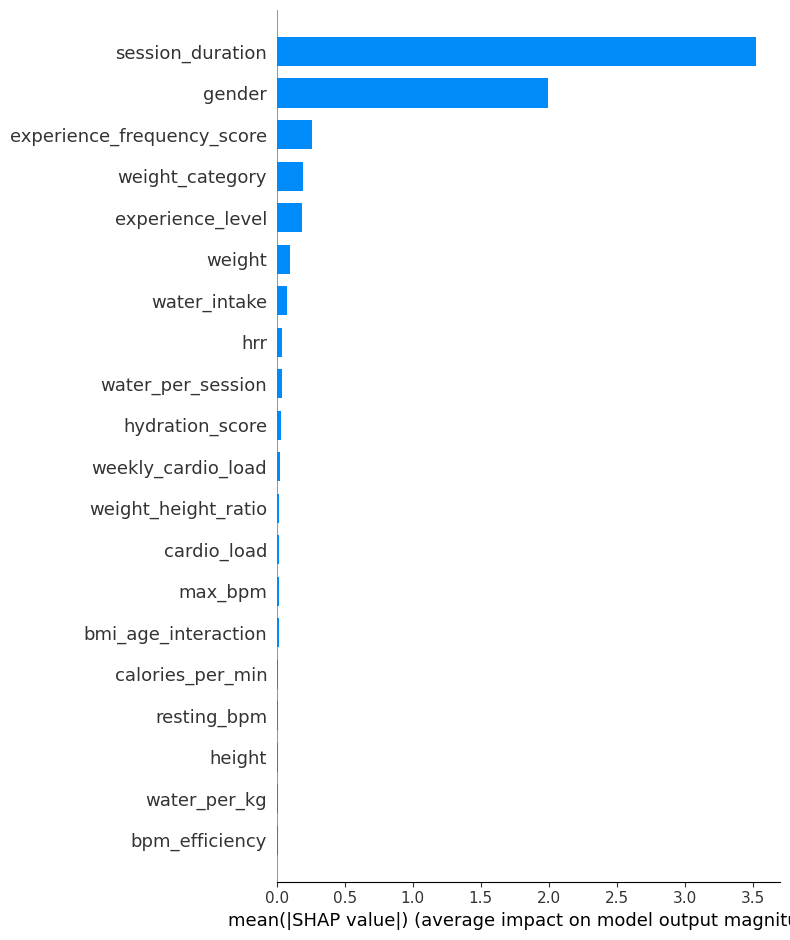

In [27]:
shap.summary_plot(
    shap_values,
    X_test_trans[:500],
    feature_names=feature_names,
    plot_type="bar",
    max_display=20
)

C:\Users\User\AppData\Local\Temp\ipykernel_18992\1437960495.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


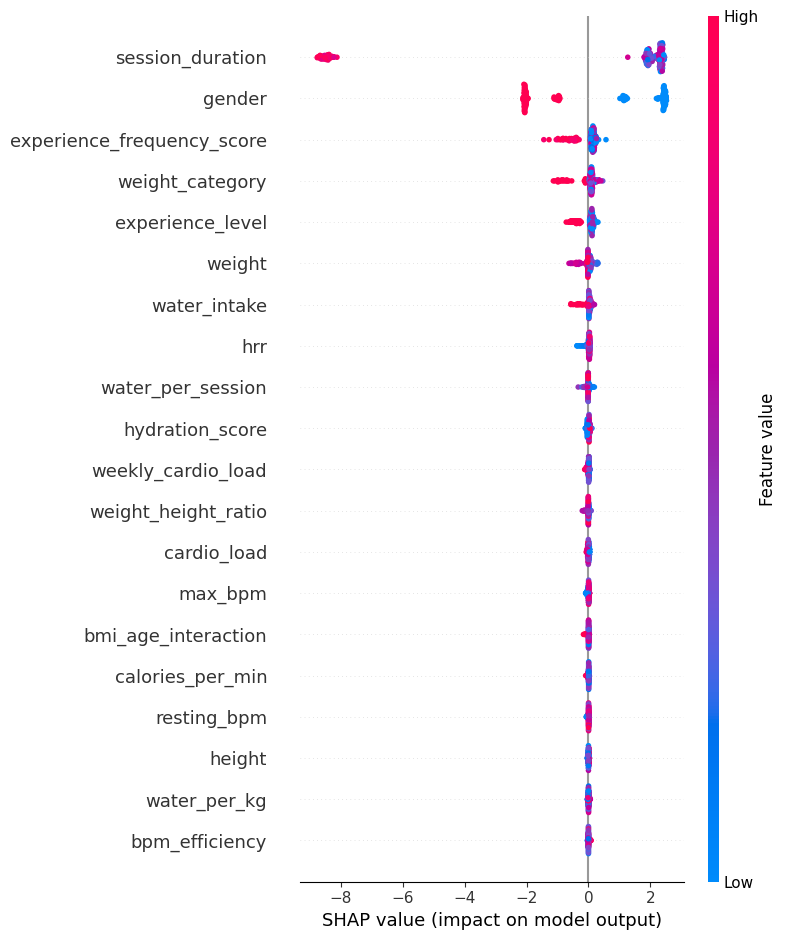

In [28]:
shap.summary_plot(
    shap_values,
    X_test_trans[:500],
    feature_names=feature_names,
    max_display=20
)

# Local SHAP

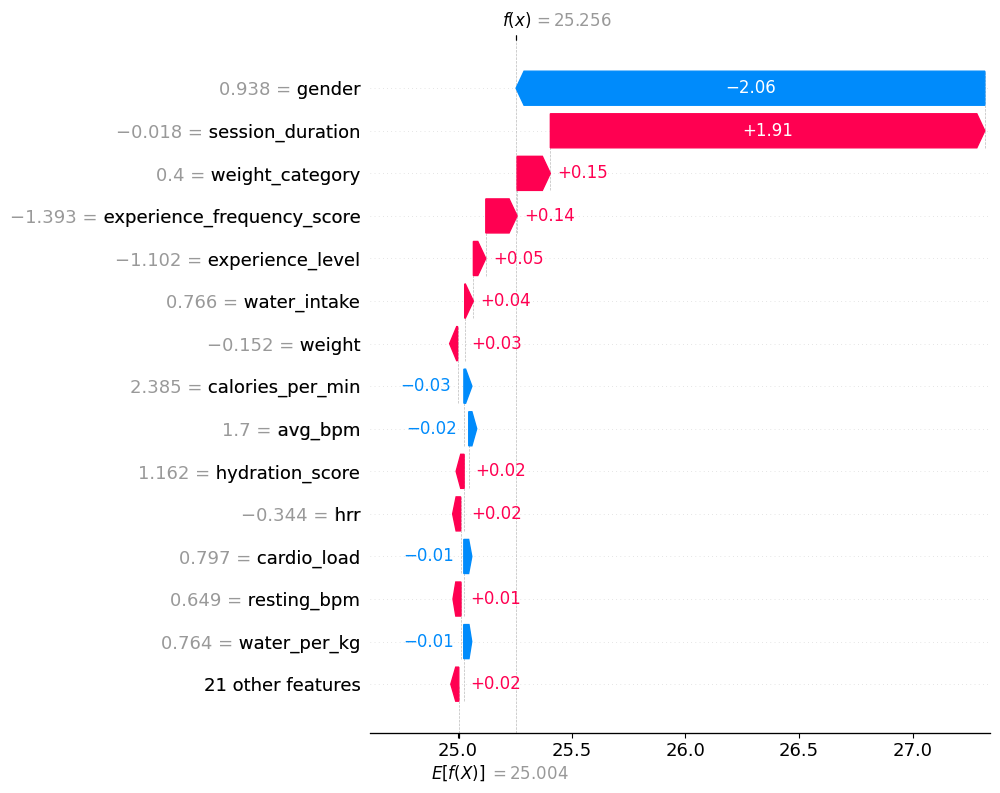

In [30]:
idx = 3

shap.plots.waterfall(
    shap_values[idx],
    max_display=15
)